# Workload 3: block size, quantile stability and what breaks the GEV

This notebook does one job: decide **how the GEV tail estimate of the audio workload (`workload3`) is set up** (block size, extremal-index gap, bootstrap block length) and **why the GEV does not fit all runs**. It does not derive budgets; `analysis_workload3.ipynb` does that with the values chosen here.

| # | Question | How it is answered |
|---|---|---|
| 1 | Which block size `b`? | stability of the **bound that the budget uses** (GEV bound at `P_GEV`) over `b`, over the run length and against the empirical quantile; goodness of fit (calibrated by a parametric bootstrap) and tail plots as diagnostics |
| 2 | Is the data stationary? | start-up transient, drift of the level, trend test, halves, autocorrelation, common drift of the two instances; effect of removing the drift |
| 3 | Which assumption of the block-maxima GEV does the workload break? | independence, stationarity, one regime for the tail (mixture of bulk and rare events), Poisson arrival of the events, content vs platform |

**Acceptance criteria** (defined in the configuration cell; the thresholds are choices of this study, not universal):

1. the block size must give at least `MIN_BLOCKS` blocks and be at least 10 × `RUNS_R` jobs (a block must be longer than the clusters of exceedances);
2. **stability:** the GEV bound at `P_GEV` varies by at most `SPREAD_MAX` over the admissible block sizes, and by at most `HALF_MAX` between the full run and each half of it;
3. **agreement:** the GEV bound is within `EMP_MAX` of the empirical (1−p) quantile of the same run;
4. the upper tail in the QQ/return-level plots has no systematic departure;
5. the goodness-of-fit p-value is reported but is **not** a gate: it is dominated by the body of the block maxima, and not rejecting does not prove a good fit nor does rejecting make the bound unusable.

A run that fails 2 or 3 should not use the GEV bound; it falls back to the empirical bound with the moving-block bootstrap (already in the procedure).

## 0. Configuration and helpers

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, kstest, kendalltau, ks_2samp, skew, kurtosis, expon

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", "{:.3f}".format)

# ======================== EDIT HERE ========================
RQ2 = Path("../workload3")
SCENARIOS  = {"single_core": ["instance0"], "multi_core": ["instance0", "instance1"]}
CONDITIONS = ["baseline1", "cache", "memory", "baseline2"]
P_GEV = 1e-3                                  # the p at which the GEV bound is used
RUNS_R = 50                                   # runs-method gap (jobs) between clusters of exceedances
BLOCK_GRID = [100, 200, 300, 500, 750, 1000, 1500, 2000]
MIN_BLOCKS = 50                               # criterion 1: at least this many blocks
MIN_B = 10 * RUNS_R                           # criterion 1: a block is longer than the clusters
BLOCK_CHOSEN = 1000                           # the block size that the analysis notebook uses (checked in section 1)
L_BOOT = 1000                                 # moving-block bootstrap block length (checked in section 1.5)
SPREAD_MAX, HALF_MAX, EMP_MAX = 0.05, 0.10, 0.10
GOF_REPS, GOF_GRID = 100, [300, 500, 1000, 2000]       # parametric-bootstrap replicates (smallest p-value = 1/(reps+1))
EVENT_FACTOR = 1.5                            # a job whose C is above EVENT_FACTOR x the median C is an "event" (section 3)
ROLL = 1000                                   # rolling window (jobs) of the level plots
# ===========================================================

rng = np.random.default_rng(0)
RUNS = [(s, c, i) for s in SCENARIOS for c in CONDITIONS for i in SCENARIOS[s]]
label = lambda r: f"{r[0][:5]}/{r[1]}/{r[2][-1]}"

def load(s, c, i):
    d = pd.read_csv(RQ2 / "results" / s / c / f"{i}.csv", usecols=["job_id", "skipped", "warmup", "cpu_ns", "start_ns"])
    return d[(d.skipped == 0) & (d.warmup == 0)].sort_values("job_id").reset_index(drop=True)

frames = {r: load(*r) for r in RUNS}
X = {r: f.cpu_ns.to_numpy() / 1e6 for r, f in frames.items()}                # C (ms) per run, job order
print(pd.Series({label(r): len(x) for r, x in X.items()}).to_string())

from math import gamma, log
from scipy.optimize import minimize

def _nll(t, m):                                    # GEV negative log-likelihood, scipy's c = -xi
    c, loc, ls = t; z = (m - loc) / np.exp(ls)
    if abs(c) < 1e-8: return float(np.sum(ls + z + np.exp(-z)))
    u = 1 - c * z
    return 1e12 if np.any(u <= 0) else float(np.sum(ls + (1 - 1 / c) * np.log(u) + u ** (1 / c)))

def fit_gev(m, multi=True):
    # maximum-likelihood GEV fit (c, loc, scale), scipy's convention: the same estimate as genextreme.fit, about 5x faster
    # (L-moment start, Nelder-Mead; multi=False uses only that start, for the bootstrap)
    m = np.sort(np.asarray(m, float)); n = len(m); i = np.arange(1, n + 1)
    b0 = m.mean(); b1 = np.sum((i - 1) / (n - 1) * m) / n; b2 = np.sum((i - 1) * (i - 2) / ((n - 1) * (n - 2)) * m) / n
    l1, l2, l3 = b0, 2 * b1 - b0, 6 * b2 - 6 * b1 + b0
    z = 2 / (3 + l3 / l2) - log(2) / log(3); k = 7.8590 * z + 2.9554 * z * z
    k = k if abs(k) > 1e-6 else 1e-6
    sc = l2 * k / ((1 - 2.0 ** -k) * gamma(1 + k)); loc = l1 - sc * (1 - gamma(1 + k)) / k
    best = None
    for k0 in ((k, -0.2, 0.2) if multi else (k,)):
        r = minimize(_nll, [k0, loc if k0 == k else np.median(m), np.log(abs(sc))], args=(m,), method="Nelder-Mead",
                     options=dict(xatol=1e-7, fatol=1e-10, maxiter=4000))
        if best is None or r.fun < best.fun: best = r
    return best.x[0], best.x[1], float(np.exp(best.x[2]))

def block_maxima(x, b):
    k = len(x) // b
    return x[: k * b].reshape(k, b).max(axis=1)

def extremal_index(x, p=P_GEV, r=RUNS_R):
    idx = np.flatnonzero(x > np.quantile(x, 1 - p))
    return (1 + np.sum(np.diff(idx) > r)) / len(idx)

def gev_bound(x, b, p=P_GEV, th=None, r=RUNS_R):
    th = extremal_index(x, p, r) if th is None else th
    c, loc, sc = fit_gev(block_maxima(x, b))
    return genextreme.ppf((1 - p) ** (b * th), c, loc, sc), -c

def gof_p(m, reps=GOF_REPS, seed=1):
    # KS test of the block maxima against the GEV fitted to them; p-value from a parametric bootstrap (the parameters are estimated)
    g = np.random.default_rng(seed)
    c, loc, sc = fit_gev(m)
    d0 = kstest(m, genextreme.cdf, args=(c, loc, sc)).statistic
    ds = []
    for _ in range(reps):
        y = genextreme.rvs(c, loc, sc, size=len(m), random_state=g)
        c2, l2, s2 = fit_gev(y, multi=False)
        ds.append(kstest(y, genextreme.cdf, args=(c2, l2, s2)).statistic)
    return (1 + sum(d >= d0 for d in ds)) / (reps + 1)

def mad_sigma(x):
    return 1.4826 * np.median(np.abs(x - np.median(x)))

def acf(x, lags):
    z = x - x.mean(); n = len(z)
    f = np.fft.rfft(z, 2 * n); a = np.fft.irfft(f * np.conj(f))[:n]
    return a[lags] / a[0]

singl/baseline1/0    100000
singl/cache/0         99997
singl/memory/0        99999
singl/baseline2/0     99996
multi/baseline1/0     99993
multi/baseline1/1     99993
multi/cache/0         99999
multi/cache/1         99999
multi/memory/0        99983
multi/memory/1        99983
multi/baseline2/0     99984
multi/baseline2/1     99984


## 1. Block size

### 1.1 Quantile stability
For every run and instance: the GEV bound of the per-job (1−p) level at `P_GEV` (block maxima of size `b`, extremal index θ from the runs estimator) for every block size of the grid. `emp` is the empirical (1−p) quantile and θ the extremal index.
`spread` = max/min of the bound over the admissible block sizes (criterion 1: enough blocks and `b ≥ MIN_B`); `halves` = max/min of the bound at `BLOCK_CHOSEN` between the full run and its first and second half; `vs emp` = bound at `BLOCK_CHOSEN` / emp − 1.
**Reading the table:** a column of the grid changes little when the bound is insensitive to `b`. A bound that falls steadily with `b` (large spread) means the model is extrapolating a feature that is not in the data.

In [2]:
rows, B = [], {}
for r in RUNS:
    x = X[r]; th = extremal_index(x)
    adm = [b for b in BLOCK_GRID if b >= MIN_B and len(x) // b >= MIN_BLOCKS]
    B[r] = {b: gev_bound(x, b, th=th)[0] for b in BLOCK_GRID if len(x) // b >= 20}
    v = [B[r][b] for b in adm]
    h = len(x) // 2; hb = [gev_bound(x[:h], BLOCK_CHOSEN)[0], gev_bound(x[h:], BLOCK_CHOSEN)[0]]
    full = B[r][BLOCK_CHOSEN]
    emp = np.quantile(x, 1 - P_GEV)
    rows.append(dict(run=label(r), emp=emp, theta=th, **{f"b={b}": B[r].get(b, np.nan) for b in BLOCK_GRID},
                     spread=max(v) / min(v), halves=max([full] + hb) / min([full] + hb), vs_emp=full / emp - 1))
stab = pd.DataFrame(rows).set_index("run")
stab["stable"] = (stab.spread - 1 <= SPREAD_MAX) & (stab.halves - 1 <= HALF_MAX) & (stab.vs_emp.abs() <= EMP_MAX)
display(stab.round(3))
print(f"stable runs: {int(stab.stable.sum())} of {len(stab)}   (spread <= {SPREAD_MAX:.0%}, halves <= {HALF_MAX:.0%}, |vs emp| <= {EMP_MAX:.0%}); b = {BLOCK_CHOSEN}")

,emp,theta,b=100,b=200,b=300,b=500,b=750,b=1000,b=1500,b=2000,spread,halves,vs_emp,stable
run,,,,,,,,,,,,,,
singl/baseline1/0,1.203,0.760,1.193,1.198,1.204,1.187,1.183,1.163,1.172,1.181,1.021,1.037,-0.033,True
singl/cache/0,1.219,0.850,1.218,1.232,1.226,1.225,1.224,1.234,1.211,1.206,1.020,1.007,0.013,True
singl/memory/0,1.153,0.810,1.157,1.168,1.165,1.166,1.156,1.163,1.164,1.174,1.009,1.060,0.008,True
singl/baseline2/0,1.162,0.840,1.179,1.179,1.178,1.164,1.152,1.152,1.152,1.160,1.010,1.032,-0.009,True
multi/baseline1/0,1.204,0.290,1.201,1.206,1.211,1.212,1.209,1.214,1.210,1.209,1.004,1.319,0.008,False
multi/baseline1/1,1.229,0.280,1.236,1.241,1.252,1.248,1.244,1.245,1.244,1.245,1.003,1.273,0.013,False
multi/cache/0,1.145,0.840,1.182,1.166,1.155,1.151,1.141,1.143,1.136,1.147,1.013,1.031,-0.002,True
multi/cache/1,1.133,0.800,1.158,1.145,1.143,1.142,1.138,1.136,1.135,1.131,1.006,1.020,0.003,True
multi/memory/0,1.112,0.710,1.122,1.121,1.115,1.116,1.111,1.109,1.109,1.111,1.007,1.003,-0.002,True


stable runs: 10 of 12   (spread <= 5%, halves <= 10%, |vs emp| <= 10%); b = 1000


### 1.2 Goodness of fit
KS test of the block maxima against the fitted GEV, with the p-value calibrated by a parametric bootstrap (`GOF_REPS` replicates; the smallest possible p-value is 1/(`GOF_REPS`+1) ≈ 0.01). `xi` is the fitted shape.
**Reading the table:** this is a diagnostic. A small p-value says the whole distribution of the maxima is not exactly a GEV; it does not say the bound at `P_GEV` is wrong (compare with 1.1).

In [3]:
rows = []
for r in RUNS:
    x = X[r]; row = dict(run=label(r))
    for b in GOF_GRID:
        if len(x) // b < 40: continue
        m = block_maxima(x, b); row[f"p b={b}"] = gof_p(m); row[f"xi b={b}"] = -fit_gev(m)[0]
    rows.append(row)
gof = pd.DataFrame(rows).set_index("run")
display(gof.round(2))

,p b=300,xi b=300,p b=500,xi b=500,p b=1000,xi b=1000,p b=2000,xi b=2000
run,,,,,,,,
singl/baseline1/0,0.010,0.450,0.420,0.680,0.440,0.940,0.140,0.750
singl/cache/0,0.010,0.570,0.020,0.740,0.010,0.760,0.060,0.910
singl/memory/0,0.010,0.590,0.020,0.700,0.020,0.750,0.060,0.600
singl/baseline2/0,0.010,0.340,0.010,0.700,0.060,0.980,0.210,0.870
multi/baseline1/0,0.010,0.380,0.760,0.540,0.080,0.570,0.330,0.560
multi/baseline1/1,0.740,0.460,0.100,0.430,0.700,0.640,0.510,0.640
multi/cache/0,0.010,0.200,0.350,0.260,0.160,0.360,0.490,0.430
multi/cache/1,0.010,0.160,0.020,0.180,0.300,0.250,0.290,0.240
multi/memory/0,0.540,0.240,0.400,0.210,0.090,0.220,0.020,0.290


### 1.3 Stability against the block size (figure)
Left: the GEV bound divided by the empirical quantile, one line per run; the band is the ±`EMP_MAX` agreement criterion and the dotted line marks the minimum block size. Right: the GEV shape ξ.

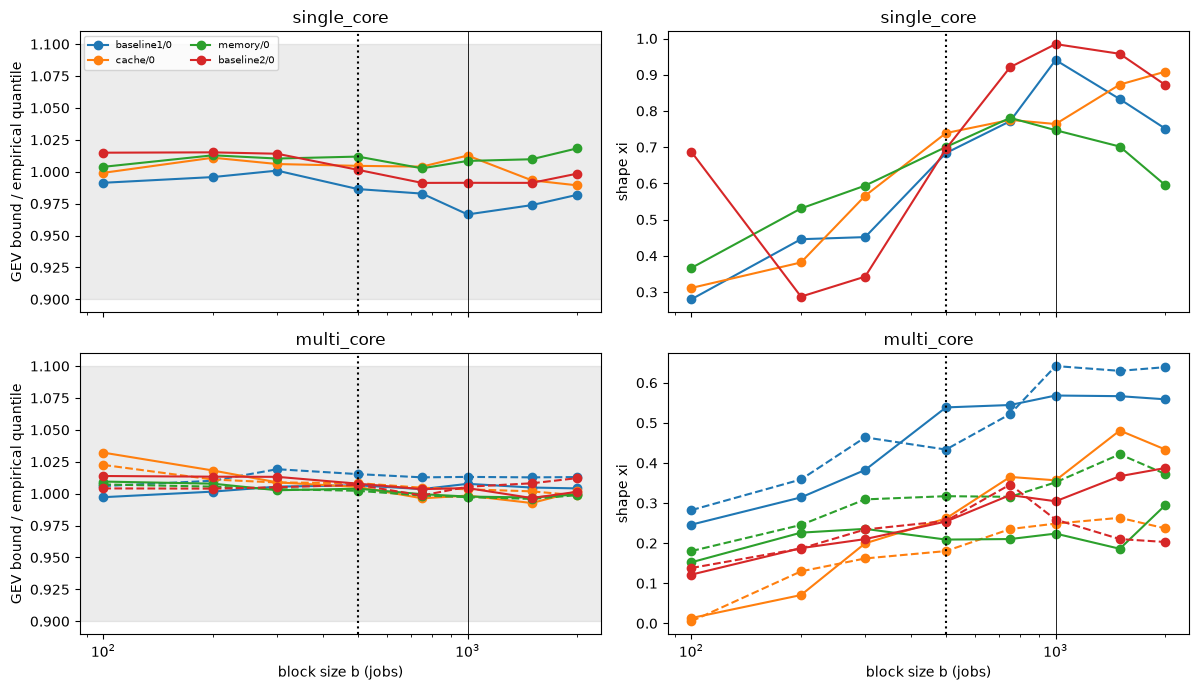

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
cols = dict(zip(CONDITIONS, ["tab:blue", "tab:orange", "tab:green", "tab:red"]))
for k, s in enumerate(SCENARIOS):
    for r in [r for r in RUNS if r[0] == s]:
        bs = [b for b in BLOCK_GRID if b in B[r]]
        emp = np.quantile(X[r], 1 - P_GEV)
        ax[k, 0].plot(bs, [B[r][b] / emp for b in bs], "o-", color=cols[r[1]], ls="-" if r[2] == "instance0" else "--", label=f"{r[1]}/{r[2][-1]}")
        ax[k, 1].plot(bs, [-fit_gev(block_maxima(X[r], b))[0] for b in bs], "o-", color=cols[r[1]], ls="-" if r[2] == "instance0" else "--")
    ax[k, 0].axhspan(1 - EMP_MAX, 1 + EMP_MAX, color="grey", alpha=.15)
    for a in ax[k]: a.axvline(MIN_B, color="k", ls=":"); a.axvline(BLOCK_CHOSEN, color="k", lw=.6); a.set_xscale("log"); a.set_title(s)
    ax[k, 0].set_ylabel("GEV bound / empirical quantile"); ax[k, 1].set_ylabel("shape xi")
ax[1, 0].set_xlabel("block size b (jobs)"); ax[1, 1].set_xlabel("block size b (jobs)"); ax[0, 0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### 1.4 Upper-tail diagnostics at `BLOCK_CHOSEN`
Return-level plot of the block maxima (instances pooled): the dots are the observed maxima, the red line the fitted GEV, the dashed horizontal line the empirical (1−p) quantile of the jobs and the dotted vertical line the return period (in blocks) that the GEV needs to reach that level: `1 / (1 − (1−p)^(b θ))`. The bound is read where the red line meets the return period of `P_GEV`.
**Reading the figure:** the red line should follow the top dots; a systematic miss of the highest dots is a tail problem, a miss of the lowest dots is only the body.

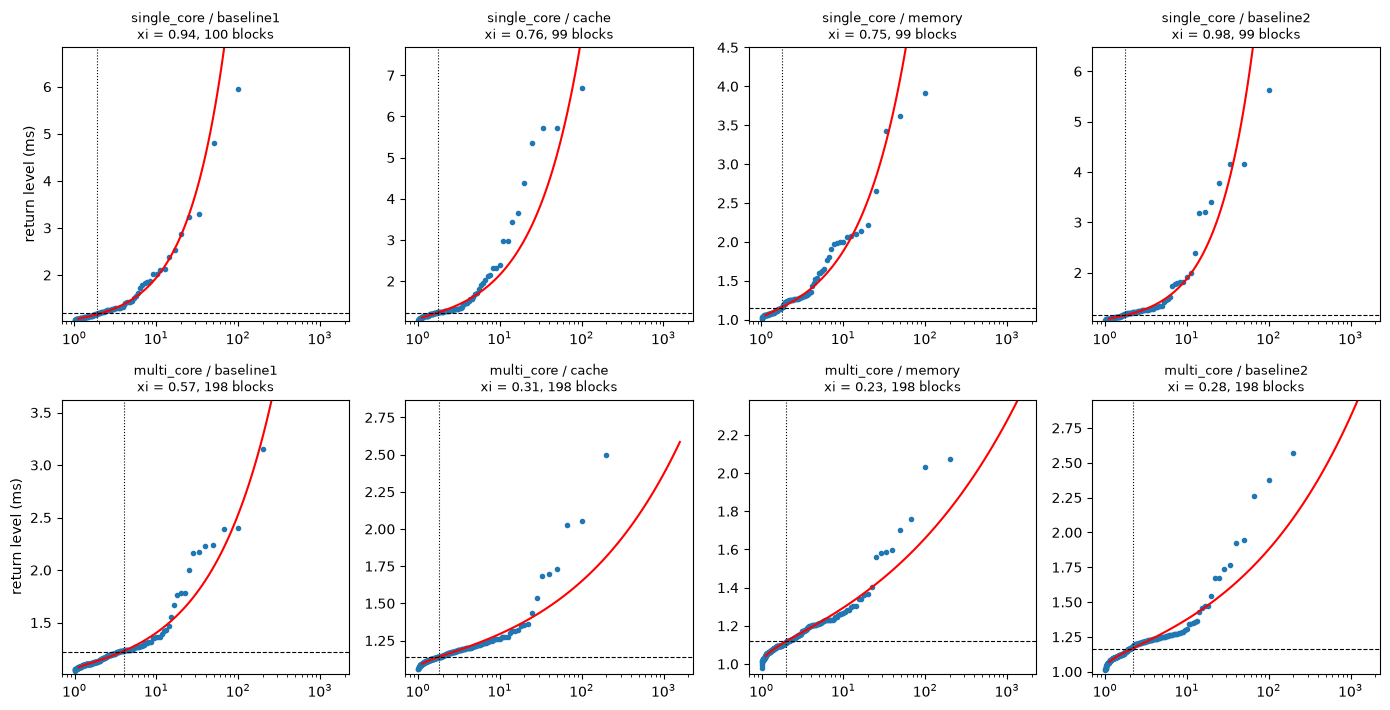

In [5]:
fig, ax = plt.subplots(len(SCENARIOS), len(CONDITIONS), figsize=(3.5 * len(CONDITIONS), 3.6 * len(SCENARIOS)), squeeze=False)
for k, s in enumerate(SCENARIOS):
    for j, c in enumerate(CONDITIONS):
        runs = [(s, c, i) for i in SCENARIOS[s]]
        m = np.concatenate([block_maxima(X[r], BLOCK_CHOSEN) for r in runs])
        cc, loc, sc = fit_gev(m)
        xs = np.sort(m); pr = np.arange(1, len(xs) + 1) / (len(xs) + 1)
        T = np.logspace(0.05, 3.2, 120)
        a = ax[k, j]
        a.semilogx(T, genextreme.isf(1 / T, cc, loc, sc), "r-"); a.scatter(1 / (1 - pr), xs, s=9)
        th = np.mean([extremal_index(X[r]) for r in runs]); emp = np.mean([np.quantile(X[r], 1 - P_GEV) for r in runs])
        a.axhline(emp, color="k", ls="--", lw=.8); a.axvline(1 / (1 - (1 - P_GEV) ** (BLOCK_CHOSEN * th)), color="k", ls=":", lw=.8)
        a.set_title(f"{s} / {c}\nxi = {-cc:.2f}, {len(m)} blocks", fontsize=9)
        a.set_ylim(xs.min() * 0.97, max(xs.max(), emp) * 1.15)
ax[0, 0].set_ylabel("return level (ms)"); ax[1, 0].set_ylabel("return level (ms)")
plt.tight_layout(); plt.show()

### 1.5 The other two parameters: `RUNS_R` and `L_BOOT`
**Extremal index θ against the gap `r`** of the runs estimator, and the GEV bound (at `BLOCK_CHOSEN`) it produces. A θ that plateaus identifies the length of the clusters; a θ that keeps falling means the exceedances are spread by something slower than a cluster (a drifting level, section 2), and then θ has no true value: a smaller θ lowers the bound, so the choice must be justified on the safe side.
**Bootstrap upper bound against the block length `L`** of the moving-block bootstrap (`B = 100` replicates): it must have reached its plateau at `L_BOOT`.

In [6]:
R_GRID = [1, 10, 20, 50, 100, 200, 500]
rows = []
for r in RUNS:
    x = X[r]
    rows.append(dict(run=label(r), **{f"theta r={g}": extremal_index(x, P_GEV, g) for g in R_GRID},
                     **{f"bound r={g}": gev_bound(x, BLOCK_CHOSEN, r=g)[0] for g in (20, 50, 100, 200)}))
rth = pd.DataFrame(rows).set_index("run")
display(rth.round(3))

L_GRID = [100, 300, 600, 1000, 2000, 5000]
def boot_ucb(x, p, L, Bn=100):
    n = len(x); k = n // L; ar = np.arange(L)
    q = [np.quantile(x[(rng.integers(0, n - L + 1, size=k)[:, None] + ar).ravel()], 1 - p) for _ in range(Bn)]
    return np.quantile(q, .95)
rows = [dict(run=label(r), emp=np.quantile(X[r], 1 - P_GEV), **{f"L={L}": boot_ucb(X[r], P_GEV, L) for L in L_GRID}) for r in RUNS]
display(pd.DataFrame(rows).set_index("run").round(3))

,theta r=1,theta r=10,theta r=20,theta r=50,theta r=100,theta r=200,theta r=500,bound r=20,bound r=50,bound r=100,bound r=200
run,,,,,,,,,,,
singl/baseline1/0,0.900,0.830,0.790,0.760,0.660,0.590,0.480,1.158,1.163,1.183,1.202
singl/cache/0,0.950,0.910,0.910,0.850,0.780,0.750,0.670,1.223,1.234,1.250,1.258
singl/memory/0,0.940,0.860,0.840,0.810,0.790,0.740,0.560,1.157,1.163,1.166,1.177
singl/baseline2/0,0.910,0.880,0.870,0.840,0.800,0.680,0.550,1.148,1.152,1.157,1.177
multi/baseline1/0,0.340,0.310,0.290,0.290,0.290,0.290,0.280,1.214,1.214,1.214,1.214
multi/baseline1/1,0.350,0.300,0.280,0.280,0.280,0.280,0.280,1.245,1.245,1.245,1.245
multi/cache/0,0.930,0.860,0.850,0.840,0.800,0.770,0.530,1.142,1.143,1.146,1.148
multi/cache/1,0.910,0.870,0.850,0.800,0.750,0.640,0.540,1.134,1.136,1.140,1.147
multi/memory/0,0.800,0.720,0.720,0.710,0.670,0.580,0.480,1.108,1.109,1.114,1.125


,emp,L=100,L=300,L=600,L=1000,L=2000,L=5000
run,,,,,,,
singl/baseline1/0,1.203,1.237,1.241,1.237,1.241,1.240,1.237
singl/cache/0,1.219,1.236,1.237,1.236,1.236,1.234,1.237
singl/memory/0,1.153,1.175,1.177,1.178,1.177,1.174,1.174
singl/baseline2/0,1.162,1.172,1.180,1.181,1.180,1.178,1.179
multi/baseline1/0,1.204,1.636,1.641,1.644,1.660,1.472,1.660
multi/baseline1/1,1.229,1.649,1.642,1.665,1.665,1.674,1.671
multi/cache/0,1.145,1.154,1.151,1.153,1.154,1.151,1.154
multi/cache/1,1.133,1.140,1.139,1.139,1.140,1.140,1.140
multi/memory/0,1.112,1.130,1.131,1.129,1.131,1.129,1.129


### 1.6 Verdict on the settings
The table gathers, per run, the criteria of the introduction. `estimator` says what the budget should use for that run.

In [7]:
verdict = stab[["emp", "spread", "halves", "vs_emp", "stable"]].join(gof[[f"p b={BLOCK_CHOSEN}", f"xi b={BLOCK_CHOSEN}"]])
verdict["estimator"] = np.where(verdict.stable, "GEV bound", "empirical (bootstrap) bound")
display(verdict.round(3))

,emp,spread,halves,vs_emp,stable,p b=1000,xi b=1000,estimator
run,,,,,,,,
singl/baseline1/0,1.203,1.021,1.037,-0.033,True,0.436,0.941,GEV bound
singl/cache/0,1.219,1.020,1.007,0.013,True,0.010,0.764,GEV bound
singl/memory/0,1.153,1.009,1.060,0.008,True,0.020,0.747,GEV bound
singl/baseline2/0,1.162,1.010,1.032,-0.009,True,0.059,0.985,GEV bound
multi/baseline1/0,1.204,1.004,1.319,0.008,False,0.079,0.568,empirical (bootstrap) bound
multi/baseline1/1,1.229,1.003,1.273,0.013,False,0.703,0.642,empirical (bootstrap) bound
multi/cache/0,1.145,1.013,1.031,-0.002,True,0.158,0.357,GEV bound
multi/cache/1,1.133,1.006,1.020,0.003,True,0.297,0.249,GEV bound
multi/memory/0,1.112,1.007,1.003,-0.002,True,0.089,0.224,GEV bound


## 2. Is the data stationary?

The block-maxima theory needs the process to be stationary (and weakly dependent). The audio task does the same work in every period (a fixed filter on a fixed-size block), so its C should be a stationary process around a constant level. This section looks for what contradicts that.

### 2.1 Tests
- `first job / median`, `first 200 / median`: start-up transient (cold caches) beyond the warm-up.
- `level range (σ)`: range of the medians of consecutive blocks of 1000 jobs, in units of the robust standard deviation of C. For an iid series the range would be about 0.1–0.3 σ (the median of 1000 jobs has σ/√1000 · 1.25).
- `Kendall τ (p)`: monotone trend of the block medians.
- `halves p50`, `halves p99.9`: second half / first half; `KS p`: two-sample KS between the halves.
- `acf`: autocorrelation of C at the lags shown. An iid series has 0; the extremal index handles dependence between nearby exceedances, but not a slowly drifting level.

In [8]:
rows = []
for r in RUNS:
    x = X[r]; n = len(x); med = np.median(x); sg = mad_sigma(x)
    bm = np.median(x[: n // 1000 * 1000].reshape(-1, 1000), axis=1)
    tau, pt = kendalltau(np.arange(len(bm)), bm)
    h = n // 2; a_, b_ = x[:h], x[h:]
    ac = acf(x, [1, 10, 100, 500])
    rows.append(dict(run=label(r), first_job_over_median=x[0] / med, first200_over_median=np.median(x[:200]) / med,
                     level_range_sigma=(bm.max() - bm.min()) / sg, tau=tau, tau_p=pt,
                     halves_p50=np.median(b_) / np.median(a_), halves_p999=np.quantile(b_, .999) / np.quantile(a_, .999),
                     ks_p=ks_2samp(a_, b_).pvalue, **{f"acf{l}": v for l, v in zip([1, 10, 100, 500], ac)}))
stat = pd.DataFrame(rows).set_index("run")
display(stat.round(3))

,first_job_over_median,first200_over_median,level_range_sigma,tau,tau_p,halves_p50,halves_p999,ks_p,acf1,acf10,acf100,acf500
run,,,,,,,,,,,,
singl/baseline1/0,1.901,1.016,1.681,-0.072,0.292,1.000,0.987,0.000,0.285,0.158,0.088,0.025
singl/cache/0,1.854,0.996,1.918,-0.131,0.055,0.997,0.996,0.000,0.242,0.121,0.071,0.035
singl/memory/0,1.886,1.026,2.274,-0.515,0.000,0.989,0.931,0.000,0.333,0.203,0.139,0.068
singl/baseline2/0,1.847,0.964,2.082,0.091,0.180,1.002,1.001,0.000,0.247,0.148,0.091,0.017
multi/baseline1/0,1.898,1.032,1.403,-0.297,0.000,0.989,0.767,0.000,0.561,0.315,0.230,0.136
multi/baseline1/1,1.854,1.038,1.659,-0.234,0.001,0.986,0.769,0.000,0.662,0.361,0.277,0.163
multi/cache/0,1.854,1.019,2.485,0.303,0.000,1.020,1.026,0.000,0.700,0.355,0.392,0.231
multi/cache/1,1.868,1.020,2.370,0.056,0.413,1.009,1.012,0.000,0.612,0.331,0.348,0.209
multi/memory/0,1.907,1.021,2.406,0.209,0.002,1.007,0.979,0.000,0.794,0.398,0.440,0.272


### 2.2 The level over the run
Rolling median (window `ROLL` jobs, line) and block maxima of `BLOCK_CHOSEN` jobs (dots) of every run, instance 0 (multi-core: dashed = instance 1). A stationary run has a flat line.

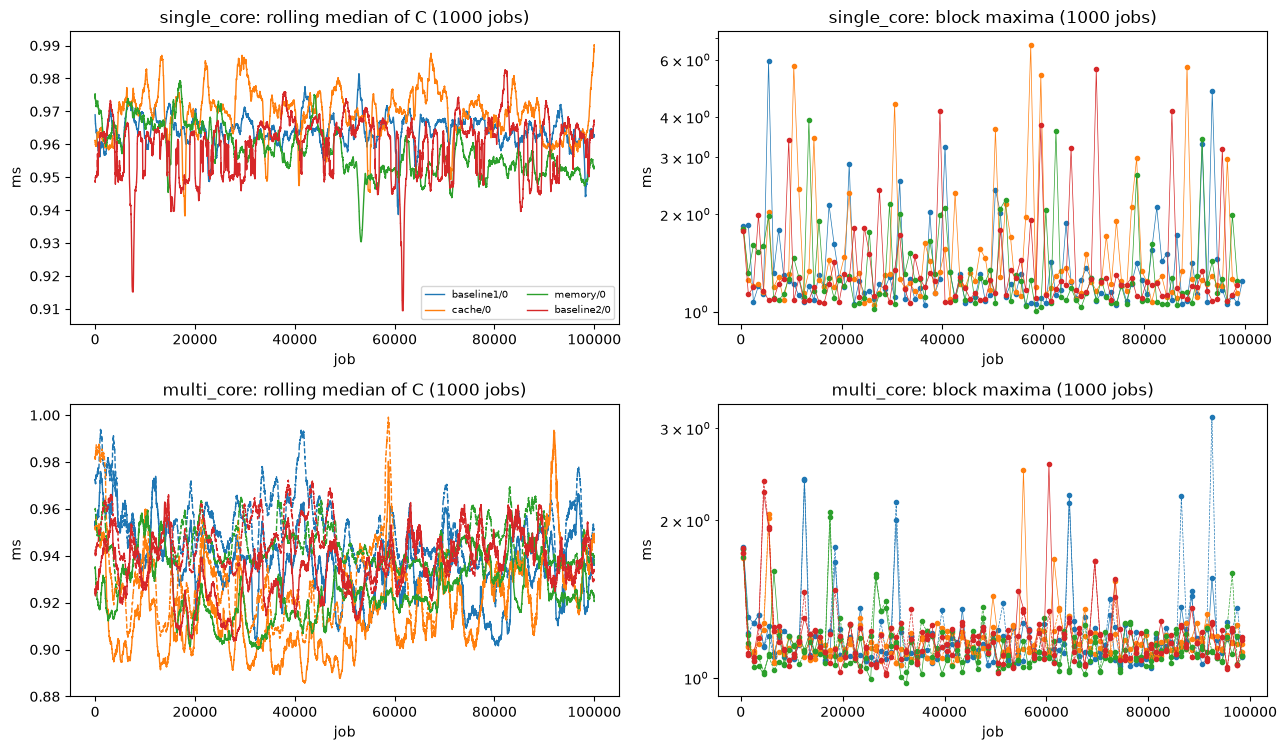

In [9]:
fig, ax = plt.subplots(len(SCENARIOS), 2, figsize=(13, 3.8 * len(SCENARIOS)), squeeze=False)
for k, s in enumerate(SCENARIOS):
    for r in [r for r in RUNS if r[0] == s]:
        x = X[r]; ls = "-" if r[2] == "instance0" else "--"
        roll = pd.Series(x).rolling(ROLL, center=True, min_periods=ROLL // 2).median()
        ax[k, 0].plot(roll.to_numpy(), ls=ls, color=cols[r[1]], label=f"{r[1]}/{r[2][-1]}", lw=1)
        m = block_maxima(x, BLOCK_CHOSEN); ax[k, 1].plot((np.arange(len(m)) + .5) * BLOCK_CHOSEN, m, ".", color=cols[r[1]], ls=ls, lw=.5)
    ax[k, 0].set_title(f"{s}: rolling median of C ({ROLL} jobs)"); ax[k, 1].set_title(f"{s}: block maxima ({BLOCK_CHOSEN} jobs)")
    ax[k, 0].set_ylabel("ms"); ax[k, 1].set_yscale("log"); ax[k, 1].set_ylabel("ms")
    ax[k, 0].set_xlabel("job"); ax[k, 1].set_xlabel("job")
ax[0, 0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### 2.3 Autocorrelation
Autocorrelation of C against the lag (instance 0). The shaded band is the 95 % band of an iid series. The curve stays outside it up to hundreds of jobs when the level wanders slowly.

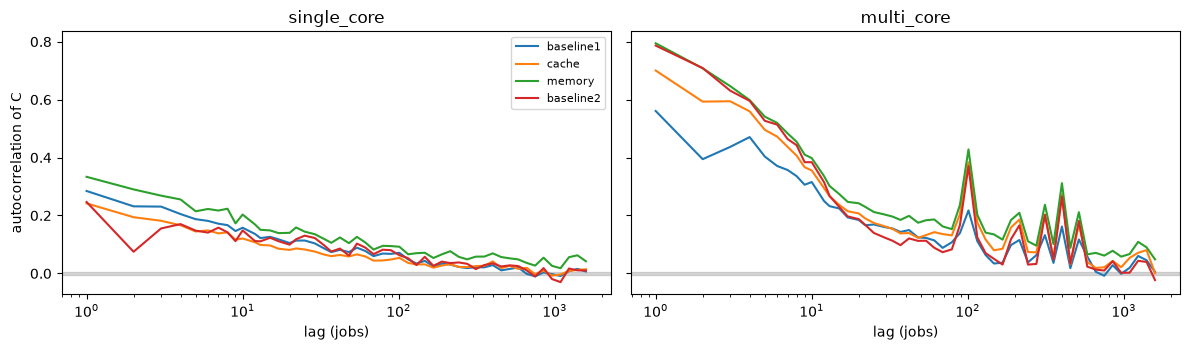

In [10]:
fig, ax = plt.subplots(1, len(SCENARIOS), figsize=(12, 3.6), sharey=True)
lags = np.unique(np.logspace(0, 3.2, 60).astype(int))
for k, s in enumerate(SCENARIOS):
    for c in CONDITIONS:
        ax[k].semilogx(lags, acf(X[(s, c, "instance0")], lags), color=cols[c], label=c)
    n = len(X[(s, "baseline1", "instance0")]); ax[k].axhspan(-1.96 / np.sqrt(n), 1.96 / np.sqrt(n), color="grey", alpha=.3)
    ax[k].set_title(s); ax[k].set_xlabel("lag (jobs)")
ax[0].set_ylabel("autocorrelation of C"); ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2.4 Is the drift common to the two instances? (multi-core)
The two instances run on different cores of the same VM. If their block medians (and block maxima) move together, the drift comes from the platform (frequency, neighbours, thermal) and not from the task.

In [11]:
rows = []
for c in CONDITIONS:
    a, b = X[("multi_core", c, "instance0")], X[("multi_core", c, "instance1")]
    n = min(len(a), len(b)) // 1000 * 1000
    ma, mb = np.median(a[:n].reshape(-1, 1000), axis=1), np.median(b[:n].reshape(-1, 1000), axis=1)
    xa, xb = a[:n].reshape(-1, 1000).max(axis=1), b[:n].reshape(-1, 1000).max(axis=1)
    rows.append(dict(condition=c, corr_block_median=np.corrcoef(ma, mb)[0, 1], corr_block_max=np.corrcoef(xa, xb)[0, 1],
                     corr_block_max_log=np.corrcoef(np.log(xa), np.log(xb))[0, 1]))
display(pd.DataFrame(rows).set_index("condition").round(3))

,corr_block_median,corr_block_max,corr_block_max_log
condition,,,
baseline1,0.843,0.766,0.795
cache,0.839,0.565,0.599
memory,0.434,0.710,0.640
baseline2,0.454,0.746,0.758


### 2.5 Effect of the drift on the fit
The level is removed with the rolling median (`ROLL` jobs): `C_detrended = C − rolling median + global median`. The GEV bound is recomputed on it. The detrended series is **not** a valid input for the budget (the drift is a real part of what the task experiences); the table only shows how much of the instability is caused by the drift.
**Reading the table:** `p` is the bootstrap goodness-of-fit p-value at `BLOCK_CHOSEN`; `spread` the stability of the bound over the block sizes as in 1.1.

In [12]:
def detrend(x):
    return x - pd.Series(x).rolling(ROLL, center=True, min_periods=ROLL // 2).median().to_numpy() + np.median(x)

def spread_of(x):
    th = extremal_index(x); adm = [b for b in BLOCK_GRID if b >= MIN_B and len(x) // b >= MIN_BLOCKS]
    v = [gev_bound(x, b, th=th)[0] for b in adm]
    return max(v) / min(v)

rows = []
for r in RUNS:
    x, xd = X[r], detrend(X[r])
    rows.append(dict(run=label(r), p_orig=gof_p(block_maxima(x, BLOCK_CHOSEN)), p_detrended=gof_p(block_maxima(xd, BLOCK_CHOSEN)),
                     spread_orig=spread_of(x), spread_detrended=spread_of(xd),
                     bound_orig=gev_bound(x, BLOCK_CHOSEN)[0], bound_detrended=gev_bound(xd, BLOCK_CHOSEN)[0],
                     theta_orig=extremal_index(x), theta_detrended=extremal_index(xd)))
display(pd.DataFrame(rows).set_index("run").round(3))

,p_orig,p_detrended,spread_orig,spread_detrended,bound_orig,bound_detrended,theta_orig,theta_detrended
run,,,,,,,,
singl/baseline1/0,0.436,0.683,1.021,1.020,1.163,1.163,0.760,0.770
singl/cache/0,0.010,0.010,1.020,1.019,1.234,1.230,0.850,0.870
singl/memory/0,0.020,0.010,1.009,1.010,1.163,1.162,0.810,0.810
singl/baseline2/0,0.059,0.040,1.010,1.006,1.152,1.158,0.840,0.840
multi/baseline1/0,0.079,0.020,1.004,1.005,1.214,1.194,0.290,0.320
multi/baseline1/1,0.703,0.069,1.003,1.006,1.245,1.233,0.280,0.290
multi/cache/0,0.158,0.703,1.013,1.009,1.143,1.136,0.840,0.870
multi/cache/1,0.297,0.455,1.006,1.003,1.136,1.130,0.800,0.850
multi/memory/0,0.089,0.030,1.007,1.003,1.109,1.104,0.710,0.720


## 3. Which assumption of the GEV does the workload break?

The block-maxima GEV rests on: (a) **weak dependence**, (b) **stationarity**, (c) the tail of C comes from **one regime** (the observations are identically distributed, so the maxima of blocks are draws from one distribution in a maximum domain of attraction), and the extremal-index correction additionally needs (d) exceedances that arrive as **clusters of independent events**. This section measures each one.

### 3.1 One regime? Bulk and rare events
An **event** is a job above `EVENT_FACTOR` × the median C of its run: the task needed at least 50 % more CPU than a normal period. For the audio filter the work per period is constant, so such a job is not caused by the content (3.4). The table compares the blocks that contain at least one event with those that do not.
**Reading the table:** if the maxima of event blocks sit far above those of bulk blocks (`gap`), the block maxima are a **mixture of two regimes** (a tight bulk and rare shocks), not draws from one GEV. `bimodality` above 0.55 is the usual sign of a bimodal distribution of the maxima. `dispersion` is the variance/mean of the events per block (1 for a Poisson process).

In [13]:
rows = []
EV = {}
for r in RUNS:
    x = X[r]; med = np.median(x); k = len(x) // BLOCK_CHOSEN
    blk = x[: k * BLOCK_CHOSEN].reshape(k, BLOCK_CHOSEN); mx = blk.max(axis=1)
    ev_blk = (blk > EVENT_FACTOR * med).sum(axis=1); has = ev_blk > 0
    EV[r] = np.flatnonzero(x > EVENT_FACTOR * med)
    n_ = len(mx); g1, g2 = skew(mx), kurtosis(mx)
    bc = (g1 ** 2 + 1) / (g2 + 3 * (n_ - 1) ** 2 / ((n_ - 2) * (n_ - 3)))
    rows.append(dict(run=label(r), events=len(EV[r]), per_100k=1e5 * len(EV[r]) / len(x), blocks_with_event=f"{has.sum()}/{k}",
                     max_bulk_blocks=np.median(mx[~has]) if (~has).any() else np.nan, max_event_blocks=np.median(mx[has]) if has.any() else np.nan,
                     gap=(np.median(mx[has]) / np.median(mx[~has])) if has.any() and (~has).any() else np.nan,
                     bimodality=bc, dispersion=ev_blk.var() / max(ev_blk.mean(), 1e-9)))
reg = pd.DataFrame(rows).set_index("run")
display(reg.round(3))

,events,per_100k,blocks_with_event,max_bulk_blocks,max_event_blocks,gap,bimodality,dispersion
run,,,,,,,,
singl/baseline1/0,27,27.000,20/100,1.141,2.024,1.773,0.784,1.471
singl/cache/0,30,30.001,26/99,1.218,2.131,1.750,0.849,0.964
singl/memory/0,23,23.000,23/99,1.136,1.987,1.749,0.748,0.768
singl/baseline2/0,21,21.001,18/99,1.166,1.956,1.678,0.831,1.074
multi/baseline1/0,62,62.004,7/99,1.117,1.779,1.593,0.791,46.600
multi/baseline1/1,63,63.004,8/99,1.132,2.167,1.914,0.802,44.237
multi/cache/0,6,6.000,6/99,1.154,1.690,1.465,0.780,0.939
multi/cache/1,2,2.000,2/99,1.138,1.895,1.665,0.767,0.980
multi/memory/0,6,6.001,4/99,1.100,1.680,1.527,0.684,1.606


Histogram of the block maxima (log scale), bulk blocks and event blocks coloured separately, for the single-core and the multi-core scenario under the memory enemy.

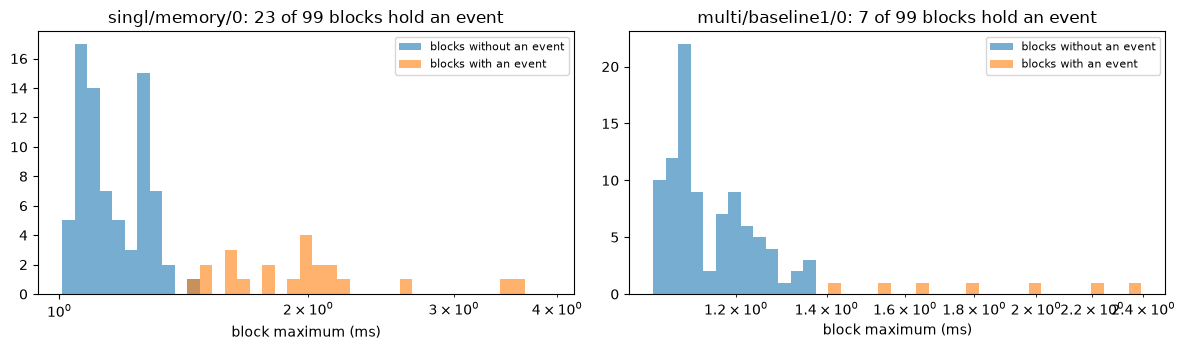

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for a, r in zip(ax, [("single_core", "memory", "instance0"), ("multi_core", "baseline1", "instance0")]):
    x = X[r]; med = np.median(x); k = len(x) // BLOCK_CHOSEN
    blk = x[: k * BLOCK_CHOSEN].reshape(k, BLOCK_CHOSEN); mx = blk.max(axis=1); has = (blk > EVENT_FACTOR * med).any(axis=1)
    bins = np.logspace(np.log10(mx.min()), np.log10(mx.max()), 40)
    a.hist(mx[~has], bins=bins, alpha=.6, label="blocks without an event"); a.hist(mx[has], bins=bins, alpha=.6, label="blocks with an event")
    a.set_xscale("log"); a.set_title(label(r) + f": {has.sum()} of {k} blocks hold an event"); a.set_xlabel("block maximum (ms)"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3.2 Do the events arrive independently?
Distribution of the gaps between events (in jobs). For a Poisson process the gaps are exponential; `KS exp p` tests that after scaling by the mean gap. Clustering of events (short gaps beyond the exponential) breaks (d); a regular period (a timer, a periodic daemon) shows as a peak in the histogram. The gaps are plotted for the pooled single-core runs and the pooled multi-core runs.

,events,mean_gap,median_gap,share_gap_below_50,ks_exp_p
run,,,,,
singl/baseline1/0,27,3630.692,1439.500,0.038,0.217
singl/cache/0,30,3310.655,2200.000,0.069,0.943
singl/memory/0,23,4425.636,2367.500,0.000,0.849
singl/baseline2/0,21,4769.750,3956.500,0.100,0.715
multi/baseline1/0,62,1519.541,1.000,0.902,0.000
multi/baseline1/1,63,1495.032,1.000,0.887,0.000
multi/cache/0,6,14707.600,6007.000,0.000,NaN
multi/cache/1,2,5889.000,5889.000,0.000,NaN
multi/memory/0,6,5216.000,5993.000,0.200,NaN


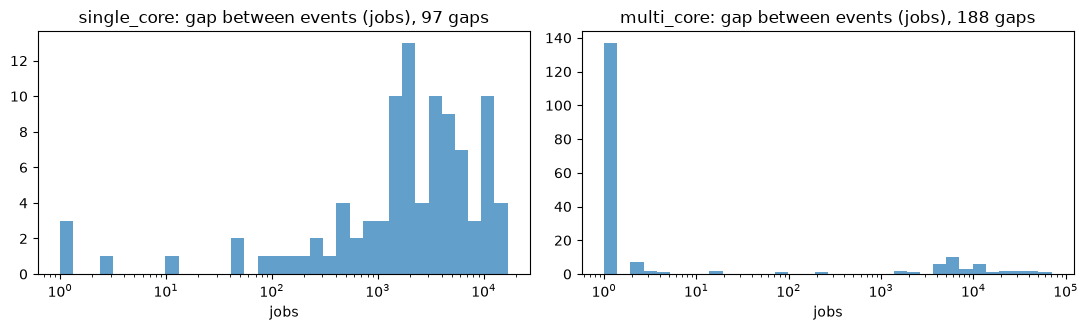

In [15]:
rows, G = [], {s: [] for s in SCENARIOS}
for r in RUNS:
    g = np.diff(EV[r])
    G[r[0]].append(g)
    rows.append(dict(run=label(r), events=len(EV[r]), mean_gap=g.mean() if len(g) else np.nan, median_gap=np.median(g) if len(g) else np.nan,
                     share_gap_below_50=(g <= 50).mean() if len(g) else np.nan, ks_exp_p=kstest(g / g.mean(), expon.cdf).pvalue if len(g) > 10 else np.nan))
display(pd.DataFrame(rows).set_index("run").round(3))
fig, ax = plt.subplots(1, len(SCENARIOS), figsize=(11, 3.4))
for a, s in zip(ax, SCENARIOS):
    g = np.concatenate(G[s]); bins = np.logspace(0, np.log10(g.max()), 35)
    a.hist(g, bins=bins, alpha=.7); a.set_xscale("log"); a.set_title(f"{s}: gap between events (jobs), {len(g)} gaps"); a.set_xlabel("jobs")
plt.tight_layout(); plt.show()

### 3.3 Are the events the same in the two instances? (multi-core)
Jobs with the same `job_id` run in the same period on the two cores. `both` = jobs that are events in both instances; `expected` = what independent instances would give (events₀ × events₁ / jobs). Many more than expected means the events come from the platform (the VM), not from the task.

In [16]:
rows = []
for c in CONDITIONS:
    a, b = frames[("multi_core", c, "instance0")], frames[("multi_core", c, "instance1")]
    m = a.merge(b, on="job_id", suffixes=("0", "1"))
    ea = m.cpu_ns0 / 1e6 > EVENT_FACTOR * np.median(X[("multi_core", c, "instance0")])
    eb = m.cpu_ns1 / 1e6 > EVENT_FACTOR * np.median(X[("multi_core", c, "instance1")])
    rows.append(dict(condition=c, events0=int(ea.sum()), events1=int(eb.sum()), both=int((ea & eb).sum()), expected=ea.sum() * eb.sum() / len(m)))
display(pd.DataFrame(rows).set_index("condition").round(3))

,events0,events1,both,expected
condition,,,,
baseline1,62,63,58,0.039
cache,6,2,2,0.000
memory,6,5,4,0.000
baseline2,25,27,22,0.007


### 3.4 Is it the content or the platform?
`frame_idx` equals `job_id`: every job processes a different slice of the clip, and the same job of two runs processes the same slice. If the content drove C, the C of the same job would be correlated between two runs (baseline1 against baseline2). A correlation near 0 means the variation is not a property of the audio. The correlation is shown for all jobs and for the 1 % largest jobs of baseline1.

In [17]:
rows = []
for s in SCENARIOS:
    for i in SCENARIOS[s]:
        a, b = frames[(s, "baseline1", i)], frames[(s, "baseline2", i)]
        m = a.merge(b, on="job_id", suffixes=("1", "2"))
        top = m.cpu_ns1 >= m.cpu_ns1.quantile(.99)
        rows.append(dict(scenario=s, instance=i, jobs=len(m), corr_all=np.corrcoef(m.cpu_ns1, m.cpu_ns2)[0, 1],
                         corr_log_all=np.corrcoef(np.log(m.cpu_ns1), np.log(m.cpu_ns2))[0, 1],
                         top1pct_of_run1_also_top1pct_in_run2=float((m.cpu_ns2[top] >= m.cpu_ns2.quantile(.99)).mean())))
display(pd.DataFrame(rows).set_index(["scenario", "instance"]).round(3))

jobs  corr_all  corr_log_all  top1pct_of_run1_also_top1pct_in_run2
scenario    instance                                                                      
single_core instance0  99996    -0.010        -0.017                                 0.012
multi_core  instance0  99977    -0.001        -0.005                                 0.010
            instance1  99977     0.037         0.040                                 0.009

### 3.5 What if the events are taken out of the block maxima?
GEV fitted only to the jobs that are not events (the event jobs are removed from the series before the block maxima are taken), against the full series. The events remain part of what the task experiences, so this is **not** a budget; it checks whether the rest of the series is a well-behaved GEV input, which would confirm that the mixture is what breaks the fit.

In [18]:
rows = []
for r in RUNS:
    x = X[r]; med = np.median(x); xb = x[x <= EVENT_FACTOR * med]
    th = extremal_index(xb); adm = [b for b in BLOCK_GRID if b >= MIN_B and len(xb) // b >= MIN_BLOCKS]
    v = [gev_bound(xb, b, th=th)[0] for b in adm]
    rows.append(dict(run=label(r), removed=len(x) - len(xb), p_full=gof_p(block_maxima(x, BLOCK_CHOSEN)), p_without_events=gof_p(block_maxima(xb, BLOCK_CHOSEN)),
                     xi_full=gev_bound(x, BLOCK_CHOSEN)[1], xi_without=gev_bound(xb, BLOCK_CHOSEN, th=th)[1],
                     spread_without=max(v) / min(v), bound_full=gev_bound(x, BLOCK_CHOSEN)[0], bound_without=gev_bound(xb, BLOCK_CHOSEN, th=th)[0],
                     emp_full=np.quantile(x, 1 - P_GEV)))
nev = pd.DataFrame(rows).set_index("run")
display(nev.round(3))

,removed,p_full,p_without_events,xi_full,xi_without,spread_without,bound_full,bound_without,emp_full
run,,,,,,,,,
singl/baseline1/0,27,0.436,0.069,0.941,0.015,1.020,1.163,1.159,1.203
singl/cache/0,30,0.010,0.663,0.764,-0.191,1.023,1.234,1.205,1.219
singl/memory/0,23,0.020,0.010,0.747,-0.070,1.026,1.163,1.148,1.153
singl/baseline2/0,21,0.059,0.010,0.985,0.014,1.020,1.152,1.156,1.162
multi/baseline1/0,62,0.079,0.010,0.568,0.245,1.011,1.214,1.147,1.204
multi/baseline1/1,63,0.703,0.030,0.642,0.185,1.005,1.245,1.162,1.229
multi/cache/0,6,0.158,0.733,0.357,-0.008,1.005,1.143,1.143,1.145
multi/cache/1,2,0.297,0.079,0.249,0.061,1.003,1.136,1.138,1.133
multi/memory/0,6,0.089,0.020,0.224,-0.024,1.005,1.109,1.109,1.112


## 4. Summary per run
One row per run: the verdict of the stability criteria (1.6), the fit diagnostic, and the evidence for each assumption.
- **dependence:** autocorrelation at lag 100.
- **stationarity:** `level_range_sigma` of 2.1 (about 0.2 for an iid series).
- **one regime:** `gap` of 3.1 (ratio of the maxima of event blocks to bulk blocks; 1 = one regime).
- **Poisson events:** dispersion of 3.1.

In [19]:
summ = verdict[["emp", "spread", "halves", "vs_emp", "stable", f"p b={BLOCK_CHOSEN}", "estimator"]].join(
    stat[["acf100", "level_range_sigma"]]).join(reg[["per_100k", "gap", "bimodality", "dispersion"]])
display(summ.round(3))

,emp,spread,halves,vs_emp,stable,p b=1000,estimator,acf100,level_range_sigma,per_100k,gap,bimodality,dispersion
run,,,,,,,,,,,,,
singl/baseline1/0,1.203,1.021,1.037,-0.033,True,0.436,GEV bound,0.088,1.681,27.000,1.773,0.784,1.471
singl/cache/0,1.219,1.020,1.007,0.013,True,0.010,GEV bound,0.071,1.918,30.001,1.750,0.849,0.964
singl/memory/0,1.153,1.009,1.060,0.008,True,0.020,GEV bound,0.139,2.274,23.000,1.749,0.748,0.768
singl/baseline2/0,1.162,1.010,1.032,-0.009,True,0.059,GEV bound,0.091,2.082,21.001,1.678,0.831,1.074
multi/baseline1/0,1.204,1.004,1.319,0.008,False,0.079,empirical (bootstrap) bound,0.230,1.403,62.004,1.593,0.791,46.600
multi/baseline1/1,1.229,1.003,1.273,0.013,False,0.703,empirical (bootstrap) bound,0.277,1.659,63.004,1.914,0.802,44.237
multi/cache/0,1.145,1.013,1.031,-0.002,True,0.158,GEV bound,0.392,2.485,6.000,1.465,0.780,0.939
multi/cache/1,1.133,1.006,1.020,0.003,True,0.297,GEV bound,0.348,2.370,2.000,1.665,0.767,0.980
multi/memory/0,1.112,1.007,1.003,-0.002,True,0.089,GEV bound,0.440,2.406,6.001,1.527,0.684,1.606


## 5. Conclusions (workload3, 12 runs of about 100k jobs)

**Settings for `analysis_workload3.ipynb`:** `BLOCK = 1000`, `L_BOOT = 1000`, `RUNS_R = 50` (sections 1.1, 1.5).
- The GEV bound at `P_GEV` is stable in **10 of 12 runs** (spread over block sizes at most 2.1 %, halves at most 6 %, within 3.3 % of the empirical quantile). The two that fail are the multi-core baseline1 instances (halves 1.27 and 1.32), see the bursts below.
- The bootstrap upper bound is on its plateau at `L = 1000` (changes by at most 1.5 % from `L = 300`, apart from the burst runs).
- `θ` has no plateau on single-core (0.90 → 0.48 for r = 1 → 500), so it has no true value there; `RUNS_R = 50` is on the conservative side (the GEV bound grows 2–3 % when r goes from 50 to 200).
- The goodness-of-fit test still rejects (p < 0.05 at b = 1000) in 4 of 12 runs although their bound is stable: it is a diagnostic, not a gate.

**What breaks the block-maxima GEV in this workload** (sections 2 and 3):
1. **One regime for the tail: broken in all 12 runs.** C is a tight bulk (median about 0.95 ms) plus rare events above 1.5 × the median. Blocks that contain an event have maxima 1.4–1.9 times those of the other blocks (`gap`), and the distribution of the maxima is bimodal (`bimodality` 0.68–0.85, above 0.55). Without the event jobs the fitted shape ξ falls from +0.2…+0.98 to between −0.19 and +0.25: the large ξ is the signature of the mixture, not of a heavy tail.
2. **Independent arrival of the events: holds on single-core, broken on multi-core baselines.** Single-core events are Poisson-like (21–30 per 100k jobs, dispersion 0.8–1.5, exponential gaps, KS p 0.2–0.9). In the multi-core baseline runs they come in **bursts** (dispersion 14–47, 73–90 % of the gaps shorter than 50 jobs, KS p = 0), and almost every burst job is an event in **both** instances at once (58 of 62 and 22 of 25, against fewer than 0.04 expected): the bursts come from the platform, not from the task. A burst that falls in one half of the run is what makes the bound of multi-core baseline1 change by 27–32 % between halves.
3. **Stationarity: present but not the cause.** The level wanders (block medians span 1.4–2.5 σ, a trend is significant in 6 runs, autocorrelation 0.07–0.44 at lag 100), but removing it changes the bound by at most 2 % and does not reliably improve the fit (2.5).
4. **The audio content is not involved:** the C of the same job in two runs has correlation between −0.01 and 0.04 (3.4).

**Consequence for the budgets.** At `P_GEV = 1e-3` with 100k jobs the bound is an interpolation inside the data, so it stays close to the empirical quantile even though the model assumption is violated; it would not at much smaller p. For runs that fail the stability criteria (multi-core baseline1) the empirical bootstrap bound must be used, and it is much larger there (1.66 ms against 1.21 ms) because the resampled blocks sometimes include a burst; the bursts are platform events and belong in `p_floor` and in the platform-event analysis (2.3 of `analysis_workload3.ipynb`), not in the tail model.